In [79]:
# 성인 남녀 얼굴 이미지 분류 (이진) - data는 구글 드라이브에 있음
# 파일명에 label로 사용할 힌트가 있음

import os, cv2, numpy as np
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

image_dir = '/content/drive/MyDrive/person_img/'
x, y = [], []
# 레이블 구하기 : 30_0_0_2017...
# gender = int(파일명.split("_")[1] 0 -> Male, 1 -> Female)

for file in os.listdir(image_dir):
  try:
    gender = int(file.split("_")[1])
    img_path = os.path.join(image_dir, file)
    img = cv2.imread(img_path)
    img = cv2.resize(img, (64, 64))
    x.append(img)
    y.append(gender)

  except:
    continue

print(x[0])
print(y[0])

[[[  9  18  15]
  [  4  13  10]
  [  3  12   9]
  ...
  [ 42  64 100]
  [ 26  47  70]
  [161 184 199]]

 [[  7  16  13]
  [  6  15  12]
  [  5  14  11]
  ...
  [ 40  61  90]
  [ 21  41  59]
  [156 178 191]]

 [[  6  19  17]
  [  5  18  16]
  [  4  16  14]
  ...
  [ 20  38  74]
  [ 26  45  72]
  [168 191 212]]

 ...

 [[ 36  29  24]
  [ 31  26  21]
  [ 26  22  21]
  ...
  [  5   1   0]
  [  5   0   1]
  [  5   0   1]]

 [[ 37  28  24]
  [ 31  26  19]
  [ 25  21  20]
  ...
  [  3   1   0]
  [  5   0   1]
  [  5   0   1]]

 [[ 36  27  23]
  [ 31  25  18]
  [ 25  21  20]
  ...
  [  3   1   0]
  [  5   0   1]
  [  5   0   1]]]
1


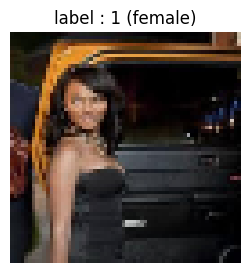

In [80]:
# 첫번쨰 이미지 시각화
import matplotlib.pyplot as plt
plt.figure(figsize=(3,3))
# opencv는 이미지를 BGR로 읽기 때문에 RGB로 변환 필요
img_rgb = cv2.cvtColor(x[0], cv2.COLOR_BGR2RGB)  # matplotlib : RGB / opencv : BGR
plt.imshow(img_rgb)
plt.title(f"label : {y[0]} ({'male' if y == 0 else 'female'})")
plt.axis('off')
plt.show()

In [81]:
# 정규화
x = np.array(x) / 255.0
y = np.array(y)

# train / test split
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(102, 64, 64, 3) (26, 64, 64, 3)
(102,) (26,)


In [82]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Input, Dropout, BatchNormalization

model = Sequential([
    Input(shape=(64, 64, 3)),
    Conv2D(16, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_18 (Conv2D)              │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 62, 62, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 29, 29, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_19 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 406,817 (1.55 MB)

 Trainable params: 406,721 (1.55 MB)

 Non-trainable params: 96 (384.00 B)

In [83]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

# 학습률을 살짝 높여서 정체 구간 탈출 시도
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

early_stopping = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

print("Re-training to separate the probabilities...")
history = model.fit(datagen.flow(x_train, y_train, batch_size=16),
                    epochs=150,
                    validation_data=(x_test, y_test),
                    callbacks=[early_stopping],
                    verbose=1)

loss, acc = model.evaluate(x_test, y_test)
print(f"Final Test Accuracy : {acc * 100:.4f}%")

Re-training to separate the probabilities...
Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 9s 527ms/step - accuracy: 0.5392 - loss: 2.1706 - val_accuracy: 0.2308 - val_loss: 0.7661
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.5392 - loss: 1.1949 - val_accuracy: 0.8077 - val_loss: 0.5548
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.6863 - loss: 0.7389 - val_accuracy: 0.7308 - val_loss: 0.5957
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.7059 - loss: 0.7689 - val_accuracy: 0.3077 - val_loss: 0.7457
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7549 - loss: 0.6194 - val_accuracy: 0.7308 - val_loss: 0.6356
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7451 - loss: 0.4963 - val_accuracy: 0.8077 - val_loss: 0.5701
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7353 - loss: 0.5311 - val_accuracy: 0.8077 - val_loss: 0.5446
Epoch 8/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7451 - l

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 559ms/step
예측값 :  [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
실제값 :  [0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 1 0]


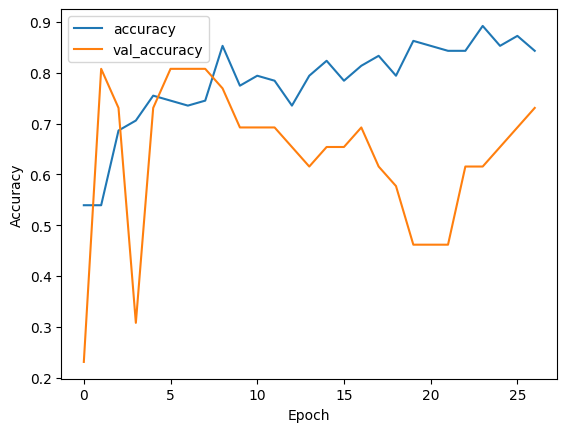

In [84]:
# 예측
pred = model.predict(x_test)
print("예측값 : ", (pred >= 0.5).astype(int).reshape(-1)) # Corrected threshold to 0.5
print("실제값 : ", y_test)

# acc 시각화
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [85]:
# 최종 학습된 모델로 10개 샘플 재예측
pred = model.predict(x_test[:10])
pred_classes = (pred >= 0.5).astype(int).reshape(-1)

print("--- Final Model Prediction Results ---")
print("예측값(Binary):", pred_classes)
print("실제값(Label): ", y_test[:10])
print("확률값(Prob):  ", np.round(pred.flatten(), 3))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
--- Final Model Prediction Results ---
예측값(Binary): [0 0 0 0 0 0 0 0 0 0]
실제값(Label):  [0 0 0 1 1 0 0 0 0 0]
확률값(Prob):   [0.345 0.442 0.316 0.287 0.488 0.249 0.351 0.306 0.337 0.424]


### 1. 클래스 불균형 확인 및 가중치 설정
현재 모델이 0.5 이상의 확률을 내놓지 못하는 현상을 해결하기 위해 클래스별 가중치를 계산합니다.

In [86]:
from sklearn.utils import class_weight
import numpy as np

# 클래스 분포 확인
unique, counts = np.unique(y_train, return_counts=True)
print("Train class distribution:", dict(zip(unique, counts)))

# 가중치 계산 (여성 데이터가 적을 경우 더 높은 가중치 부여)
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: weights[i] for i in range(len(weights))}
print("적용할 클래스 가중치:", class_weights)

Train class distribution: {np.int64(0): np.int64(72), np.int64(1): np.int64(30)}
적용할 클래스 가중치: {0: np.float64(0.7083333333333334), 1: np.float64(1.7)}


### 2. 가중치를 적용한 모델 재학습
`class_weight` 파라미터를 사용하여 모델이 소수 클래스(여성)의 특징을 더 강하게 학습하도록 유도합니다.

In [87]:
print("Re-training with class weights...")
# 기존 모델의 가중치를 초기화하거나 새로 컴파일하여 학습을 새로 시작
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(datagen.flow(x_train, y_train, batch_size=16),
                    epochs=100,
                    validation_data=(x_test, y_test),
                    class_weight=class_weights,
                    callbacks=[early_stopping],
                    verbose=1)

Re-training with class weights...
Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 505ms/step - accuracy: 0.6863 - loss: 0.9647 - val_accuracy: 0.5769 - val_loss: 0.6687
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7059 - loss: 0.5967 - val_accuracy: 0.5769 - val_loss: 0.6994
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7255 - loss: 0.6031 - val_accuracy: 0.4615 - val_loss: 0.8824
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7549 - loss: 0.6937 - val_accuracy: 0.2308 - val_loss: 1.3983
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.7157 - loss: 0.7487 - val_accuracy: 0.2308 - val_loss: 1.5609
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7549 - loss: 0.5792 - val_accuracy: 0.2692 - val_loss: 1.4962
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7451 - loss: 0.7593 - val_accuracy: 0.2692 - val_loss: 1.5696
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.7745 - loss: 0.5923

### 3. 결과 시각화 (5명 샘플)
학습 결과가 확률값(Prob)의 범위를 어떻게 변화시켰는지 확인합니다.

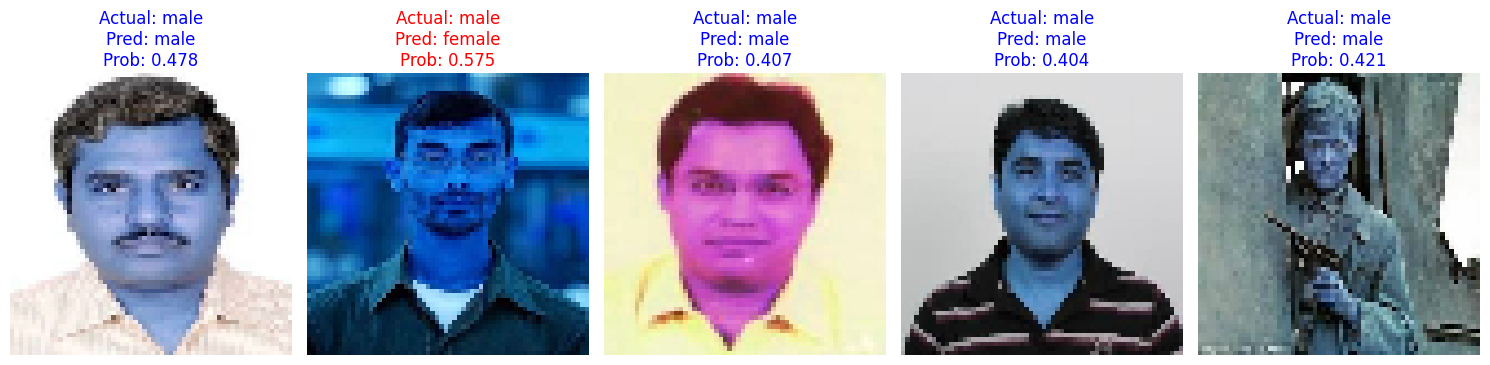

In [88]:
import matplotlib.pyplot as plt
import numpy as np

# 무작위로 5개 인덱스 선택
random_indices = np.random.choice(len(x_test), 5, replace=False)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(random_indices):
    # 최신 모델로 다시 예측
    prob = model.predict(x_test[idx:idx+1], verbose=0)[0][0]
    pred_class = 'female' if prob >= 0.5 else 'male'
    actual_class = 'female' if y_test[idx] == 1 else 'male'

    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[idx])
    color = 'blue' if pred_class == actual_class else 'red'
    plt.title(f"Actual: {actual_class}\nPred: {pred_class}\nProb: {prob:.3f}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


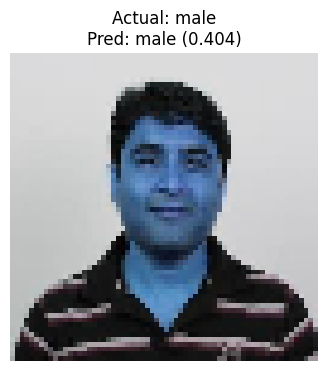

In [89]:
# 마지막 샘플 인덱스
idx = -1

# 예측 수행
last_pred = model.predict(x_test[idx:])[0][0]
last_pred_class = 'female' if last_pred >= 0.5 else 'male'
actual_class = 'female' if y_test[idx] == 1 else 'male'

# 시각화
plt.figure(figsize=(4, 4))
# x_test는 이미 0~1 사이로 정규화되어 있으므로 그대로 사용
img_to_show = x_test[idx]

plt.imshow(img_to_show)
plt.title(f"Actual: {actual_class}\nPred: {last_pred_class} ({last_pred:.3f})")
plt.axis('off')
plt.show()

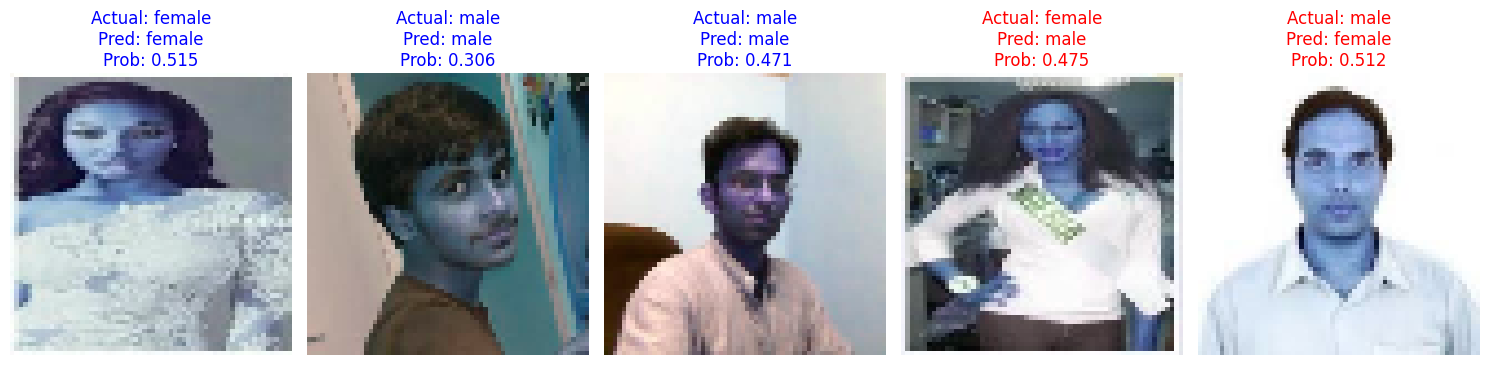

In [90]:
import matplotlib.pyplot as plt
import numpy as np

# 무작위로 5개 인덱스 선택
random_indices = np.random.choice(len(x_test), 5, replace=False)

plt.figure(figsize=(15, 5))

for i, idx in enumerate(random_indices):
    # 예측 수행
    prob = model.predict(x_test[idx:idx+1], verbose=0)[0][0]
    pred_class = 'female' if prob >= 0.5 else 'male'
    actual_class = 'female' if y_test[idx] == 1 else 'male'

    # 서브플롯 설정
    plt.subplot(1, 5, i + 1)
    plt.imshow(x_test[idx])
    color = 'blue' if pred_class == actual_class else 'red'
    plt.title(f"Actual: {actual_class}\nPred: {pred_class}\nProb: {prob:.3f}", color=color)
    plt.axis('off')

plt.tight_layout()
plt.show()

# 현재 모델은 학습데이터 부족으로 좋은 결과를 기대하기 어렵다.

In [91]:
unique, counts = np.unique(y_train, return_counts=True)
print("Train class distribution:", dict(zip(unique, counts)))

# 클래스 불균형을 해결하기 위해 가중치 계산
from sklearn.utils import class_weight
weights = class_weight.compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = {i: weights[i] for i in range(len(weights))}
print("Class weights to apply:", class_weights)

Train class distribution: {np.int64(0): np.int64(72), np.int64(1): np.int64(30)}
Class weights to apply: {0: np.float64(0.7083333333333334), 1: np.float64(1.7)}


In [78]:
# 가중치를 적용하여 재학습
print("Re-training with class weights...")
history = model.fit(datagen.flow(x_train, y_train, batch_size=16),
                    epochs=100,
                    validation_data=(x_test, y_test),
                    class_weight=class_weights,
                    callbacks=[early_stopping],
                    verbose=1)

Re-training with class weights...
Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 7s 572ms/step - accuracy: 0.8039 - loss: 0.6192 - val_accuracy: 0.5000 - val_loss: 0.6956
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7157 - loss: 0.8489 - val_accuracy: 0.4615 - val_loss: 0.7150
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7059 - loss: 0.5736 - val_accuracy: 0.6154 - val_loss: 0.7180
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8039 - loss: 0.4961 - val_accuracy: 0.5385 - val_loss: 0.7411
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8039 - loss: 0.6764 - val_accuracy: 0.7308 - val_loss: 0.5358
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7157 - loss: 0.6064 - val_accuracy: 0.7692 - val_loss: 0.5138
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.8039 - loss: 0.3905 - val_accuracy: 0.7308 - val_loss: 0.5236
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.7059 - loss: 0.7532